In [32]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [33]:
housing=pd.read_csv("housing.csv")

In [34]:

df=pd.DataFrame(housing)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [35]:
df["income_cut"]=pd.cut(df["median_income"],bins=[1,1.5,3,4,5.5,7,8.5,10,11.5],labels=[1,2,3,4,5,6,7,8])

In [36]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cut
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,6
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2


In [37]:
print(df["income_cut"].isnull().sum())

291


In [39]:
df["income_cut"]=df["income_cut"].astype(float)
df["income_cut"]=df["income_cut"].fillna(df["income_cut"].mean())

In [40]:
print(df["income_cut"].isnull().sum())

0


In [41]:
import matplotlib.pyplot as plt

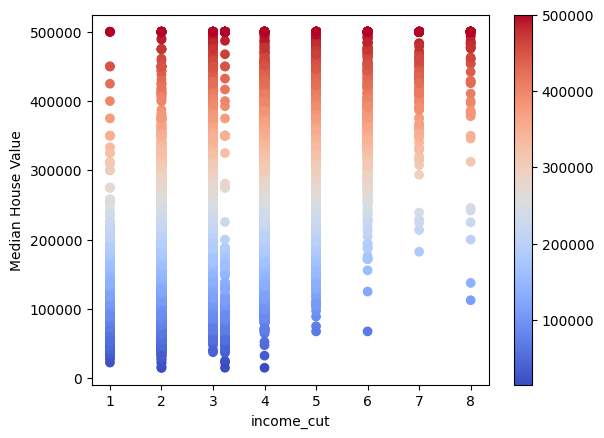

In [42]:
plt.scatter(df["income_cut"], df["median_house_value"],
            c=df["median_house_value"], cmap="coolwarm")
plt.colorbar()
plt.xlabel("income_cut")
plt.ylabel("Median House Value")
plt.show()


In [43]:
split=StratifiedShuffleSplit(n_splits=1,test_size=0.3,random_state=42)
for train_size,test_size in split.split(df,df["income_cut"]):
    train_size=housing.iloc[train_size]
    test_size=housing.iloc[test_size]

In [46]:
housing=test_size.copy()
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
8950,-118.46,34.02,39.0,3599.0,776.0,1569.0,763.0,5.2571,405400.0,<1H OCEAN
17791,-121.81,37.37,26.0,2987.0,539.0,1931.0,518.0,5.1099,213100.0,<1H OCEAN
7241,-118.12,34.00,31.0,3281.0,768.0,2385.0,733.0,2.7308,173800.0,<1H OCEAN
7634,-118.29,33.84,23.0,3626.0,799.0,2321.0,731.0,4.7393,237900.0,<1H OCEAN
5184,-118.27,33.94,38.0,1314.0,318.0,1080.0,285.0,1.5872,89800.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
13026,-121.21,38.67,11.0,5500.0,956.0,2827.0,946.0,4.1071,145800.0,INLAND
12450,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,INLAND
7621,-118.25,33.87,18.0,6812.0,1263.0,3704.0,1216.0,4.2500,169200.0,<1H OCEAN
4691,-118.37,34.07,50.0,2519.0,NaN,1117.0,516.0,4.3667,405600.0,<1H OCEAN


In [48]:
housing_labels=housing["median_house_value"].copy()
housing=housing.drop("median_house_value",axis=1)

In [49]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
8950,-118.46,34.02,39.0,3599.0,776.0,1569.0,763.0,5.2571,<1H OCEAN
17791,-121.81,37.37,26.0,2987.0,539.0,1931.0,518.0,5.1099,<1H OCEAN
7241,-118.12,34.00,31.0,3281.0,768.0,2385.0,733.0,2.7308,<1H OCEAN
7634,-118.29,33.84,23.0,3626.0,799.0,2321.0,731.0,4.7393,<1H OCEAN
5184,-118.27,33.94,38.0,1314.0,318.0,1080.0,285.0,1.5872,<1H OCEAN
...,...,...,...,...,...,...,...,...,...
13026,-121.21,38.67,11.0,5500.0,956.0,2827.0,946.0,4.1071,INLAND
12450,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,INLAND
7621,-118.25,33.87,18.0,6812.0,1263.0,3704.0,1216.0,4.2500,<1H OCEAN
4691,-118.37,34.07,50.0,2519.0,NaN,1117.0,516.0,4.3667,<1H OCEAN


In [52]:
num_attributes=df.drop("ocean_proximity",axis=1)
char=df["ocean_proximity"]

In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Sample dataset
data = {
    "age": [10, 20, 5],
    "rooms": [3, 2, 4],
    "city": ["Mumbai", "Delhi", "Pune"],
    "furnished": ["yes", "no", "yes"],
    "price": [80, 60, 90]
}

df = pd.DataFrame(data)

# Define feature columns
numeric_cols = ["age", "rooms"]
categorical_cols = ["city", "furnished"]

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(), categorical_cols)
    ]
)

# Create full pipeline with model
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

# Split X and y
X = df.drop("price", axis=1)
y = df["price"]

# Fit pipeline
pipeline.fit(X, y)

print("Pipeline created and fitted successfully!")


Pipeline created and fitted successfully!
